# Baseline e Modelação

> Objetivo: construir e avaliar três modelos baseline em ordem: Regressão Logística, Árvore de Decisão e Random Forest.

## Estrutura desta secção
1. Preparação dos dados
2. Baseline: Regressão Logística
3. Baseline: Árvore de Decisão
4. Baseline: Random Forest

In [ ]:
# importações de bibliotecas
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

## 1) Preparação dos dados

Nesta fase convertemos Grupo_pre e Sexo para categóricas, definimos X_raw e y, fazemos o split estratificado e aplicamos one-hot encoding para todos os modelos baseline.

In [ ]:
# Converter variáveis categóricas e definir X_raw/y
ortho_clean["Grupo_pre"] = ortho_clean["Grupo_pre"].astype("category")
ortho_clean["Sexo"] = ortho_clean["Sexo"].astype("category")

X_raw = ortho_clean.drop("mudanca_CPAK", axis=1)
y = ortho_clean["mudanca_CPAK"]

In [ ]:
# Verificação de valores nulos em X_raw
X_raw.isnull().sum()

Idade        0
Sexo         0
Peso         0
Altura_cm    0
IMC          0
Grupo_pre    0
Fle_0        0
EVA_0        0
PM6_0        0
WD_0         0
WR_0         0
WAtotal_0    0
WT_0         0
dtype: int64

In [10]:
# Verificação de valores nulos em y
y.isnull().sum()

np.int64(0)

In [ ]:
# Split estratificado dos dados em treino e teste
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.30, random_state=42, stratify=y)

In [ ]:
# One-hot encoding para todos os modelos
colunas_categoricas = ["Grupo_pre", "Sexo"]

X_train_ohe = pd.get_dummies(X_train_raw, columns=colunas_categoricas, drop_first=True)
X_test_ohe = pd.get_dummies(X_test_raw, columns=colunas_categoricas, drop_first=True)
X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

# Versão completa para validação cruzada
X_ohe = pd.get_dummies(X_raw, columns=colunas_categoricas, drop_first=True)
X_ohe = X_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

In [ ]:
# Verificação da distribuição da target no conjunto de treino
print("Distribuição da Target (CPAK) - Treino")
print("N. observações Treino", len(X_train_raw))
print(y_train.value_counts(normalize=True))

Distribuição da Target (CPAK) - Treino
N. observações Treino 183
mudanca_CPAK
0    0.901639
1    0.098361
Name: proportion, dtype: float64


In [ ]:
# Verificação da distribuição da target no conjunto de teste

print("Distribuição da Target (CPAK) - Teste")
print("N. observações Teste", len(X_test_raw))
print(y_test.value_counts(normalize=True))

Distribuição da Target (CPAK) - Teste
N. observações Teste 79
mudanca_CPAK
0    0.898734
1    0.101266
Name: proportion, dtype: float64


## 2) Baseline: Regressão Logística

Treino do modelo baseline de regressão logística e avaliação com métricas de classificação.

In [ ]:
# Treino do baseline com Regressão Logística
clf_LR = LogisticRegression(random_state=42)
clf_LR = clf_LR.fit(X_train_ohe, y_train)

# Previsões no conjunto de teste
y_pred_LR = clf_LR.predict(X_test_ohe)
y_pred_LR_prob = clf_LR.predict_proba(X_test_ohe)
print(y_pred_LR_prob)
print(y_pred_LR)

[[9.94280849e-01 5.71915082e-03]
 [9.95761608e-01 4.23839168e-03]
 [9.99799616e-01 2.00383568e-04]
 [9.64181033e-01 3.58189674e-02]
 [9.93979748e-01 6.02025181e-03]
 [9.92111223e-01 7.88877662e-03]
 [9.61981518e-01 3.80184821e-02]
 [9.96239500e-01 3.76049980e-03]
 [2.37091161e-01 7.62908839e-01]
 [8.40136888e-01 1.59863112e-01]
 [9.99692221e-01 3.07779428e-04]
 [8.77927885e-01 1.22072115e-01]
 [9.95861054e-01 4.13894628e-03]
 [9.99426162e-01 5.73838361e-04]
 [9.98069354e-01 1.93064622e-03]
 [9.97777568e-01 2.22243161e-03]
 [8.73780693e-01 1.26219307e-01]
 [9.93804256e-01 6.19574424e-03]
 [9.99987188e-01 1.28119849e-05]
 [9.99085768e-01 9.14232412e-04]
 [9.74398693e-01 2.56013074e-02]
 [9.99950168e-01 4.98318073e-05]
 [5.67166074e-01 4.32833926e-01]
 [9.83084319e-01 1.69156806e-02]
 [9.40510352e-01 5.94896483e-02]
 [9.95393647e-01 4.60635323e-03]
 [9.85869253e-01 1.41307469e-02]
 [9.96991343e-01 3.00865712e-03]
 [9.87920528e-01 1.20794723e-02]
 [2.19381638e-01 7.80618362e-01]
 [9.265353

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
# Matriz de confusão do baseline (Regressão Logística)
c_matrix_LR = confusion_matrix(y_test, y_pred_LR)
print(c_matrix_LR)


[[65  6]
 [ 5  3]]


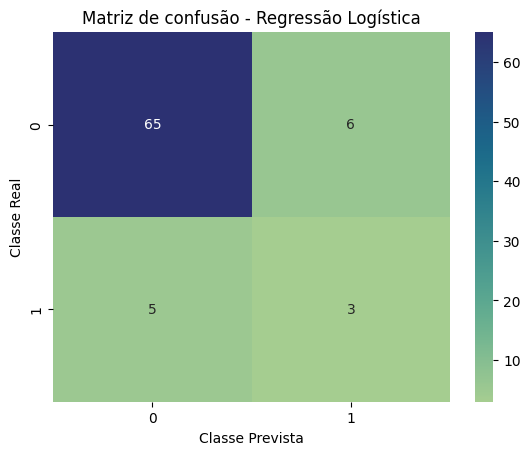

In [64]:
# Visualização da matriz de confusão
sns.heatmap(c_matrix_LR, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matriz de confusão - Regressão Logística")
plt.show()

In [65]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_LR))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92        71
           1       0.33      0.38      0.35         8

    accuracy                           0.86        79
   macro avg       0.63      0.65      0.64        79
weighted avg       0.87      0.86      0.86        79



In [66]:
# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_LR)
print("AUC:", auc)

AUC: 0.6452464788732395


In [ ]:
# Validação cruzada (K-fold) para estimar generalização
pred_cross_LR = cross_val_predict(clf_LR, X_ohe, y)

print(classification_report(y, pred_cross_LR, digits=4))


              precision    recall  f1-score   support

           0     0.9080    0.9619    0.9342       236
           1     0.2500    0.1154    0.1579        26

    accuracy                         0.8779       262
   macro avg     0.5790    0.5386    0.5460       262
weighted avg     0.8427    0.8779    0.8571       262



c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

## 3) Baseline: Árvore de Decisão

Treino do modelo baseline de árvore de decisão e avaliação com métricas de classificação.

In [ ]:
# Treino do baseline com Árvore de Decisão
clf_DT = tree.DecisionTreeClassifier(random_state=42)
clf_DT = clf_DT.fit(X_train_ohe, y_train)

# Previsões no conjunto de teste
y_pred_DT = clf_DT.predict(X_test_ohe)
y_pred_DT

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [69]:
# Matriz de confusão do baseline (Árvore de Decisão)
confusion_m = confusion_matrix(y_test, y_pred_DT)
print(confusion_m)

[[69  2]
 [ 7  1]]


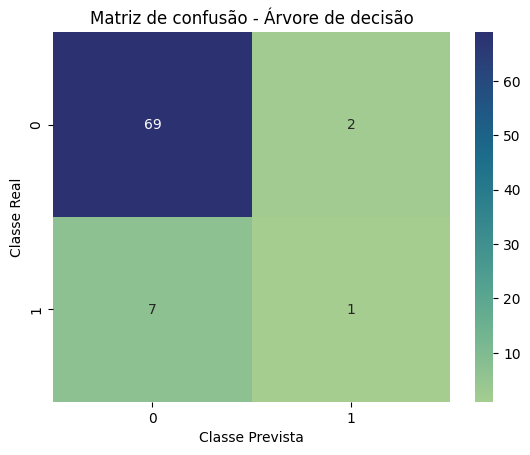

In [70]:
# Visualização da matriz de confusão
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matriz de confusão - Árvore de decisão")
plt.show()

In [71]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_DT))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94        71
           1       0.33      0.12      0.18         8

    accuracy                           0.89        79
   macro avg       0.62      0.55      0.56        79
weighted avg       0.85      0.89      0.86        79



In [72]:
# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_DT)
print("AUC:", auc)

AUC: 0.5484154929577465


In [ ]:
# Validação cruzada (K-fold) para estimar generalização
pred = cross_val_predict(clf_DT, X_ohe, y)

print(classification_report(y, pred, digits=4))

              precision    recall  f1-score   support

           0     0.9227    0.9110    0.9168       236
           1     0.2759    0.3077    0.2909        26

    accuracy                         0.8511       262
   macro avg     0.5993    0.6094    0.6039       262
weighted avg     0.8586    0.8511    0.8547       262



## 4) Baseline: Random Forest

Treino do modelo baseline de floresta aleatória e avaliação com métricas de classificação.

In [ ]:
# Treino do baseline com Random Forest
clf_RF = RandomForestClassifier(random_state=42)
clf_RF = clf_RF.fit(X_train_ohe, y_train)

# Previsões no conjunto de teste
y_pred_RF = clf_RF.predict(X_test_ohe)
print(y_pred_RF)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0]


In [ ]:
confusion_matrix_RF = confusion_matrix(y_test, y_pred_RF)
print(confusion_matrix_RF)

[[71  0]
 [ 7  1]]


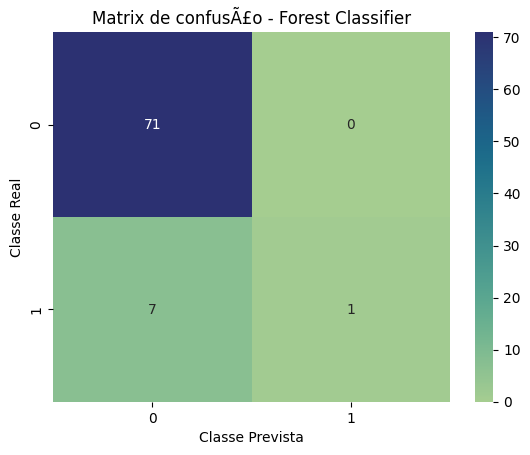

In [ ]:
sns.heatmap(confusion_matrix_RF, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matrix de confusão - Forest Classifier")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        71
           1       1.00      0.12      0.22         8

    accuracy                           0.91        79
   macro avg       0.96      0.56      0.59        79
weighted avg       0.92      0.91      0.88        79



In [ ]:
#Area Under the Curve (AUC)
auc = roc_auc_score(y_test, y_pred_RF)
print("AUC:", auc)

AUC: 0.5625


In [ ]:
# Cross Validation: K-fold
pred_cross_RF = cross_val_predict(clf_RF, X_ohe, y)

print(classification_report(y, pred_cross_RF, digits=4))



              precision    recall  f1-score   support

           0     0.9105    0.9915    0.9493       236
           1     0.6000    0.1154    0.1935        26

    accuracy                         0.9046       262
   macro avg     0.7553    0.5535    0.5714       262
weighted avg     0.8797    0.9046    0.8743       262

